# 04 — Customer analysis and RFM segmentation

## Goal
Measure observed repeat behavior and segment customers using completed purchases. We use `customer_unique_id`, not `customer_id`: one unique customer may appear in multiple order-linked customer records.

### Scope and limitation
This is an anonymised historical extract (2016–2018). Monetary is **observed checkout value during this dataset window**, not a prediction of lifetime value.

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables'
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

order_fact = pd.read_csv(PROCESSED_DIR / 'order_fact.csv', parse_dates=['order_purchase_timestamp'])
customers = pd.read_csv(PROCESSED_DIR / 'customers_clean.csv')

customer_orders = (order_fact.query("order_status == 'delivered'")
    .merge(customers[['customer_id', 'customer_unique_id', 'customer_state']],
           on='customer_id', how='left', validate='one_to_one'))
if customer_orders['customer_unique_id'].isna().any():
    raise ValueError('Missing customer_unique_id after merge. Recheck the customer relationship.')

print(f'Delivered orders in customer scope: {len(customer_orders):,}')
print(f'Unique customers in customer scope: {customer_orders.customer_unique_id.nunique():,}')

Delivered orders in customer scope: 96,478
Unique customers in customer scope: 93,358


## 1. Observed repeat-purchase behavior

Frequency is based on delivered orders only. A repeat customer has at least two delivered orders in the observation window.

In [7]:
customer_frequency = (customer_orders.groupby('customer_unique_id', as_index=False)
    .agg(delivered_orders=('order_id', 'nunique'),
         observed_checkout_value=('order_item_total', 'sum')))
repeat_summary = pd.DataFrame({
    'metric': ['Unique customers', 'One-time customers', 'Repeat customers', 'Repeat-customer rate', 'Average delivered orders per customer'],
    'value': [
        len(customer_frequency),
        int((customer_frequency['delivered_orders'] == 1).sum()),
        int((customer_frequency['delivered_orders'] >= 2).sum()),
        (customer_frequency['delivered_orders'] >= 2).mean(),
        customer_frequency['delivered_orders'].mean()
    ]
})
repeat_summary.to_csv(TABLE_DIR / '04_repeat_customer_summary.csv', index=False)
display(repeat_summary)
display(customer_frequency['delivered_orders'].value_counts().sort_index().rename_axis('delivered_orders').reset_index(name='customers').head(10))

,metric,value
0,Unique customers,"93,358.00"
1,One-time customers,"90,557.00"
2,Repeat customers,"2,801.00"
3,Repeat-customer rate,0.03
4,Average delivered orders per customer,1.03


,delivered_orders,customers
0,1,90557
1,2,2573
2,3,181
3,4,28
4,5,9
5,6,5
6,7,3
7,9,1
8,15,1


## 2. Build RFM metrics

The reference date is one day after the latest observed purchase—not today's date—so the analysis remains reproducible.

- **Recency:** days since the most recent delivered purchase; lower is better.
- **Frequency:** delivered-order count; higher is better.
- **Monetary:** observed checkout value; higher is better.

In [8]:
reference_date = customer_orders['order_purchase_timestamp'].max().normalize() + pd.Timedelta(days=1)
rfm = (customer_orders.groupby('customer_unique_id', as_index=False)
    .agg(last_purchase_date=('order_purchase_timestamp', 'max'),
         frequency=('order_id', 'nunique'),
         monetary=('order_item_total', 'sum'),
         primary_state=('customer_state', lambda s: s.mode().iat[0] if not s.mode().empty else pd.NA)))
rfm['recency_days'] = (reference_date - rfm['last_purchase_date'].dt.normalize()).dt.days

# Rank before qcut so repeated recency/monetary values do not break quartile creation.
rfm['R_score'] = pd.qcut(rfm['recency_days'].rank(method='first', ascending=False), 4, labels=[1, 2, 3, 4]).astype(int)
# Frequency is discrete and heavily concentrated at one order; use transparent business bands instead of arbitrary tie-breaking quartiles.
rfm['F_score'] = pd.cut(rfm['frequency'], bins=[0, 1, 2, 3, float('inf')], labels=[1, 2, 3, 4], include_lowest=True).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

display(rfm[['recency_days', 'frequency', 'monetary', 'R_score', 'F_score', 'M_score']].describe().T)
print('Reference date:', reference_date.date())

,count,mean,std,min,25%,50%,75%,max
recency_days,"93,358.00",238.48,152.60,1.00,115.00,219.00,347.00,714.00
frequency,"93,358.00",1.03,0.21,1.00,1.00,1.00,1.00,15.00
monetary,"93,358.00",165.17,226.29,9.59,63.01,107.78,182.51,"13,664.08"
R_score,"93,358.00",2.50,1.12,1.00,1.25,2.50,3.75,4.00
F_score,"93,358.00",1.03,0.20,1.00,1.00,1.00,1.00,4.00
M_score,"93,358.00",2.50,1.12,1.00,1.25,2.50,3.75,4.00


Reference date: 2018-08-30


## 3. Create actionable customer segments

These are transparent business rules, not a machine-learning model. They are mutually exclusive and can be revised later if the business provides a different retention strategy.

In [9]:
def assign_segment(row):
    if row.R_score >= 3 and row.F_score >= 3 and row.M_score >= 3:
        return 'Champions'
    if row.R_score >= 3 and row.F_score >= 3:
        return 'Loyal customers'
    if row.R_score >= 3 and row.frequency == 2:
        return 'Potential repeat customers'
    if row.R_score >= 3 and row.frequency == 1:
        return 'New / recent one-time'
    if row.R_score <= 2 and row.frequency >= 2:
        return 'At-risk repeat customers'
    return 'Hibernating one-time'

rfm['segment'] = rfm.apply(assign_segment, axis=1)
segment_summary = (rfm.groupby('segment', as_index=False)
    .agg(customers=('customer_unique_id', 'nunique'),
         avg_recency_days=('recency_days', 'mean'),
         avg_frequency=('frequency', 'mean'),
         observed_checkout_value=('monetary', 'sum'),
         avg_checkout_value=('monetary', 'mean'))
    .sort_values('observed_checkout_value', ascending=False))
segment_summary['customer_share_pct'] = segment_summary['customers'] / len(rfm) * 100
segment_summary['value_share_pct'] = segment_summary['observed_checkout_value'] / rfm['monetary'].sum() * 100
segment_summary.to_csv(TABLE_DIR / '04_rfm_segment_summary.csv', index=False)
rfm.to_csv(PROCESSED_DIR / 'customer_rfm.csv', index=False)
display(segment_summary)

,segment,customers,avg_recency_days,avg_frequency,observed_checkout_value,avg_checkout_value,customer_share_pct,value_share_pct
4,New / recent one-time,45136,112.27,1.00,"7,297,809.27",161.68,48.35,47.33
2,Hibernating one-time,45421,364.98,1.00,"7,257,777.02",159.79,48.65,47.07
5,Potential repeat customers,1401,113.82,2.00,"409,327.65",292.17,1.50,2.65
0,At-risk repeat customers,1258,352.97,2.08,"378,395.15",300.79,1.35,2.45
1,Champions,141,106.25,3.55,"76,376.39",541.68,0.15,0.50
3,Loyal customers,1,3.00,3.00,88.27,88.27,0.00,0.00


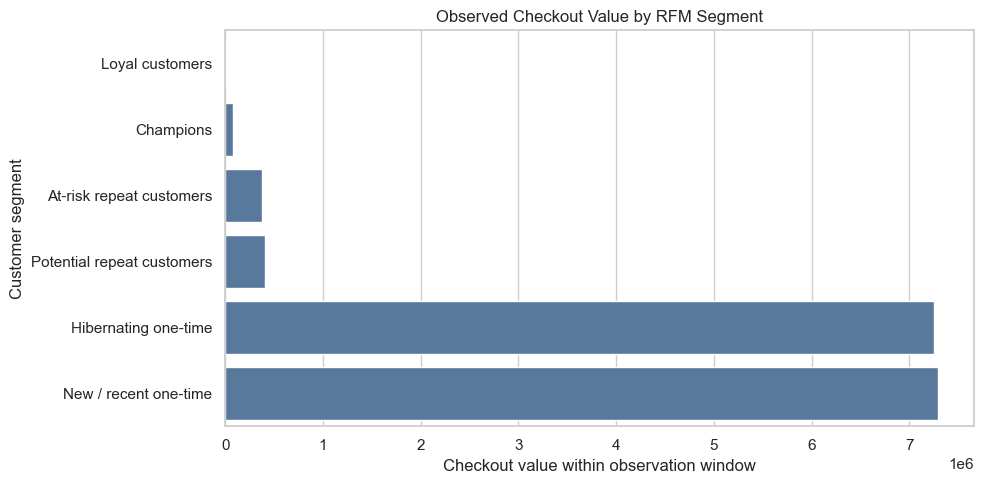

,customer_unique_id,frequency,monetary,recency_days,segment
3724,0a0a92112bd4c708ca5fde585afaa872,1,"13,664.08",335,Hibernating one-time
79636,da122df9eeddfedc1dc1f5349a1a690c,2,"7,571.63",516,At-risk repeat customers
43168,763c8b1c9c68a0229c42c9fc6f662b93,1,"7,274.88",46,New / recent one-time
80463,dc4802a71eae9be1dd28f5d788ceb526,1,"6,929.31",564,Hibernating one-time
25436,459bef486812aa25204be022145caa62,1,"6,922.21",36,New / recent one-time
93081,ff4159b92c40ebe40454e3e6a7c35ed6,1,"6,726.66",463,Hibernating one-time
23411,4007669dec559734d6f53e029e360987,1,"6,081.54",279,Hibernating one-time
87148,eebb5dda148d3893cdaf5b5ca3040ccb,1,"4,764.34",499,Hibernating one-time
26640,48e1ac109decbb87765a3eade6854098,1,"4,681.78",69,New / recent one-time
73127,c8460e4251689ba205045f3ea17884a1,4,"4,655.88",22,Champions


In [10]:
plot_data = segment_summary.sort_values('observed_checkout_value')
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_data, x='observed_checkout_value', y='segment', color='#4c78a8')
plt.title('Observed Checkout Value by RFM Segment')
plt.xlabel('Checkout value within observation window')
plt.ylabel('Customer segment')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '04_rfm_segment_value.png', dpi=150, bbox_inches='tight')
plt.show()

top_customers = rfm.sort_values('monetary', ascending=False).head(20)
top_customers.to_csv(TABLE_DIR / '04_top_customers_observed_value.csv', index=False)
display(top_customers[['customer_unique_id', 'frequency', 'monetary', 'recency_days', 'segment']])

## 4. Segment actions

Use the final segment table as evidence for recommendations—not individual customer IDs. The extract is anonymised, so recommendations should target segment behavior rather than personal data.

- **Champions:** protect service quality; offer early access or premium bundles.
- **Loyal customers:** use cross-sell and category recommendations.
- **Potential repeat customers:** encourage a third purchase with tailored cross-sell offers.
- **New / recent one-time:** encourage the second purchase soon after the first.
- **At-risk repeat customers:** test re-engagement offers and investigate delivery experience.
- **Hibernating one-time:** prioritize scalable onboarding or win-back campaigns, not costly one-to-one treatment.